# Assignment 10: N-Gram Language Model for Auto-Complete
## Building a Smart Auto-Complete System Using N-Gram Probability Models

This notebook builds a better auto-complete algorithm using N-gram language models,
similar in principle to models used for machine translation, authorship attribution,
and speech recognition.

### Topics Covered:
1. Text Corpus Preparation and Preprocessing
2. N-Gram Frequency Counting (Unigram, Bigram, Trigram, 4-gram)
3. Probability Estimation with Laplace (Add-1) Smoothing
4. Add-k Smoothing
5. Stupid Backoff Model
6. Linear Interpolation Model
7. Auto-Complete Engine
8. Perplexity Evaluation and Model Comparison
9. Visualisation
10. Interactive Demo

## 1. Install Required Libraries

In [1]:
!pip install nltk matplotlib numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports and NLTK Downloads

In [2]:
import warnings
warnings.filterwarnings('ignore')

import re
import math
import random
import string
from collections import defaultdict, Counter

import nltk
nltk.download('brown')
nltk.download('reuters')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

from nltk.corpus import brown, reuters
from nltk.tokenize import word_tokenize, sent_tokenize

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

random.seed(42)
np.random.seed(42)

print("Libraries imported successfully!")
print("NLTK corpora: Brown + Reuters")

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\brown.zip.
[nltk_data] Downloading package reuters to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ayush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Libraries imported successfully!
NLTK corpora: Brown + Reuters


## 3. Corpus Preparation and Preprocessing

We use two well-known NLTK corpora:
- **Brown corpus** – 1 million words of American English from 15 genres (news, fiction, etc.)
- **Reuters corpus** – News wire articles (~1.3 million words)

The combined corpus is split 90 / 10 into **train** and **test** sets.

In [3]:
# ── Special boundary tokens ──────────────────────────────────────────────────
BOS = '<s>'    # beginning-of-sentence
EOS = '</s>'   # end-of-sentence
UNK = '<UNK>'  # unknown word


def preprocess_sentence(tokens, lower=True):
    """Clean a list of tokens and return lowercased words (no punctuation)."""
    cleaned = []
    for tok in tokens:
        tok = tok.lower() if lower else tok
        # keep only alphabetic tokens
        if tok.isalpha():
            cleaned.append(tok)
    return cleaned


def build_corpus(sentences, n_max=4):
    """
    Wrap each sentence with (n_max-1) BOS tokens and one EOS token and
    return a list-of-lists ready for N-gram counting.
    """
    padded = []
    for sent in sentences:
        clean = preprocess_sentence(sent)
        if len(clean) >= 2:           # skip extremely short sentences
            padded.append([BOS] * (n_max - 1) + clean + [EOS])
    return padded


# ── Load sentences ───────────────────────────────────────────────────────────
print("Loading corpora ...")
brown_sents   = list(brown.sents())[:40_000]    # first 40 000 sentences
reuters_sents = list(reuters.sents())[:20_000]  # first 20 000 sentences
all_sentences = brown_sents + reuters_sents
random.shuffle(all_sentences)

# ── Train / test split ───────────────────────────────────────────────────────
split = int(0.90 * len(all_sentences))
train_raw = all_sentences[:split]
test_raw  = all_sentences[split:]

train_corpus = build_corpus(train_raw)
test_corpus  = build_corpus(test_raw)

print(f"Training sentences : {len(train_corpus):,}")
print(f"Test sentences     : {len(test_corpus):,}")
print(f"\nSample sentence    : {train_corpus[0]}")

Loading corpora ...
Training sentences : 52,970
Test sentences     : 5,887

Sample sentence    : ['<s>', '<s>', '<s>', 'the', 'onset', 'profile', 'and', 'completion', 'profile', 'are', 'constructed', 'to', 'serve', 'as', 'norms', 'for', 'children', '</s>']


## 4. Vocabulary and Unknown-Word Handling

Words appearing **fewer than 2 times** in training are replaced with `<UNK>` so the
model can generalise to unseen words at test time.

In [4]:
MIN_FREQ = 2

# Count every token in the training corpus
raw_counts = Counter(tok for sent in train_corpus for tok in sent)

# Vocabulary = tokens that exceed the frequency threshold + special tokens
VOCAB = {tok for tok, cnt in raw_counts.items() if cnt >= MIN_FREQ}
VOCAB.update({BOS, EOS, UNK})


def replace_unk(sent):
    """Replace out-of-vocabulary tokens with <UNK>."""
    return [tok if tok in VOCAB else UNK for tok in sent]


train_corpus = [replace_unk(s) for s in train_corpus]
test_corpus  = [replace_unk(s) for s in test_corpus]

print(f"Vocabulary size    : {len(VOCAB):,}")
print(f"Total train tokens : {sum(len(s) for s in train_corpus):,}")
print(f"Total test tokens  : {sum(len(s) for s in test_corpus):,}")

Vocabulary size    : 25,127
Total train tokens : 1,330,539
Total test tokens  : 147,577


## 5. N-Gram Frequency Counting

We count **unigrams, bigrams, trigrams, and 4-grams** from the training corpus.
An N-gram is a contiguous sequence of N tokens.

In [5]:
def count_ngrams(corpus, n):
    """Return a Counter of all n-grams (as tuples) in the corpus."""
    counts = Counter()
    for sent in corpus:
        for i in range(len(sent) - n + 1):
            counts[tuple(sent[i:i + n])] += 1
    return counts


print("Counting N-grams ...")
unigram_counts = count_ngrams(train_corpus, 1)
bigram_counts  = count_ngrams(train_corpus, 2)
trigram_counts = count_ngrams(train_corpus, 3)
fourgram_counts= count_ngrams(train_corpus, 4)

TOTAL_UNIGRAMS = sum(unigram_counts.values())
V = len(VOCAB)   # vocabulary size used in smoothing

print("=" * 55)
print(f"  {'N-gram':<12} {'Unique':>12}  {'Tokens':>14}")
print("  " + "-" * 42)
print(f"  {'Unigram':<12} {len(unigram_counts):>12,}  {TOTAL_UNIGRAMS:>14,}")
print(f"  {'Bigram':<12} {len(bigram_counts):>12,}")
print(f"  {'Trigram':<12} {len(trigram_counts):>12,}")
print(f"  {'4-gram':<12} {len(fourgram_counts):>12,}")
print(f"\n  Vocabulary size : {V:,}")

# Top bigrams
print("\nTop 10 most frequent bigrams:")
for bg, cnt in bigram_counts.most_common(10):
    print(f"  {' '.join(bg):<30} {cnt:>6,}")

Counting N-grams ...
  N-gram             Unique          Tokens
  ------------------------------------------
  Unigram            25,127       1,330,539
  Bigram            403,349
  Trigram           817,574
  4-gram            978,621

  Vocabulary size : 25,127

Top 10 most frequent bigrams:
  <s> <s>                        105,940
  of the                          9,903
  <s> the                         8,247
  in the                          6,659
  to the                          3,310
  said </s>                       2,639
  for the                         2,331
  on the                          2,253
  and the                         2,155
  u s                             1,984


## 6. Probability Estimation with Laplace (Add-1) Smoothing

Without smoothing, any unseen N-gram has probability 0, making the language model
useless for test data. **Laplace smoothing** adds 1 to every count:

$$P_{Laplace}(w_n \mid w_1 \dots w_{n-1}) =
  \frac{C(w_1 \dots w_n) + 1}{C(w_1 \dots w_{n-1}) + V}$$

In [6]:
class NgramModel:
    """
    N-gram language model with pluggable smoothing.

    Parameters
    ----------
    n         : order (1 = unigram, 2 = bigram, …)
    smoothing : 'laplace' | 'add_k' | 'none'
    k         : add-k constant (used only when smoothing='add_k')
    """

    def __init__(self, n, smoothing='laplace', k=0.1):
        self.n         = n
        self.smoothing = smoothing
        self.k         = k
        self.ngram_counts  = None
        self.context_counts= None   # (n-1)-gram counts (denominators)

    def train(self, corpus):
        """Fit the model on a preprocessed corpus (list of token lists)."""
        self.ngram_counts   = count_ngrams(corpus, self.n)
        if self.n > 1:
            self.context_counts = count_ngrams(corpus, self.n - 1)
        else:
            self.context_counts = None
        return self

    def prob(self, word, context):
        """
        Estimate P(word | context).

        context : tuple of (n-1) preceding tokens
        """
        ngram   = context + (word,)
        c_ngram = self.ngram_counts.get(ngram, 0)

        if self.n == 1:
            c_ctx = TOTAL_UNIGRAMS
        else:
            c_ctx = self.context_counts.get(context, 0)

        if self.smoothing == 'none':
            if c_ctx == 0:
                return 0.0
            return c_ngram / c_ctx

        elif self.smoothing in ('laplace', 'add_k'):
            alpha = 1.0 if self.smoothing == 'laplace' else self.k
            return (c_ngram + alpha) / (c_ctx + alpha * V)

        raise ValueError(f"Unknown smoothing: {self.smoothing}")

    def log_prob(self, word, context):
        p = self.prob(word, context)
        return math.log2(p) if p > 0 else float('-inf')

    def top_k_predictions(self, context, k=5):
        """
        Return the top-k most probable next words given a context tuple.
        Only words in VOCAB are considered.
        """
        scores = []
        for word in VOCAB:
            if word in (BOS, UNK):
                continue
            scores.append((word, self.prob(word, context)))
        scores.sort(key=lambda x: -x[1])
        return scores[:k]


# ── Train all four models ─────────────────────────────────────────────────────
print("Training N-gram models (Laplace smoothing) ...")
models = {}
for order, name in [(1, 'Unigram'), (2, 'Bigram'), (3, 'Trigram'), (4, '4-gram')]:
    m = NgramModel(n=order, smoothing='laplace').train(train_corpus)
    # attach pre-counted dicts to avoid recomputation
    if order == 1:
        m.ngram_counts = unigram_counts
    elif order == 2:
        m.ngram_counts = bigram_counts;  m.context_counts = unigram_counts
    elif order == 3:
        m.ngram_counts = trigram_counts; m.context_counts = bigram_counts
    else:
        m.ngram_counts = fourgram_counts;m.context_counts = trigram_counts
    models[name] = m
    print(f"  {name} model ready.")

print("\nAll models trained!")

Training N-gram models (Laplace smoothing) ...
  Unigram model ready.
  Bigram model ready.
  Trigram model ready.
  4-gram model ready.

All models trained!


## 7. Add-k Smoothing

A generalisation of Laplace smoothing: add a small constant **k < 1** instead of 1.
This avoids over-assigning probability mass to unseen events.

$$P_{add\_k}(w_n \mid w_1 \dots w_{n-1}) =
  \frac{C(w_1 \dots w_n) + k}{C(w_1 \dots w_{n-1}) + kV}$$

In [7]:
# Build an add-k trigram model and compare predictions on a sample context
trigram_addk = NgramModel(n=3, smoothing='add_k', k=0.01)
trigram_addk.ngram_counts   = trigram_counts
trigram_addk.context_counts = bigram_counts

context = (BOS, BOS)
sample_context_words = ('the', 'government')
ctx2 = sample_context_words  # bigram context for trigram prediction

print("LAPLACE vs ADD-k SMOOTHING (trigram, context='the government')")
print("=" * 62)
print(f"  {'Word':<15} {'Laplace P':>12}  {'Add-k P (k=0.01)':>18}")
print("  " + "-" * 50)

top_words_laplace = models['Trigram'].top_k_predictions(ctx2, k=10)
top_words_addk    = trigram_addk.top_k_predictions(ctx2, k=10)

# Merge the word lists
all_words = list({w for w, _ in top_words_laplace} |
                 {w for w, _ in top_words_addk})

lp_dict = dict(top_words_laplace)
ak_dict = dict(top_words_addk)

for w in sorted(all_words, key=lambda x: -lp_dict.get(x, 0))[:10]:
    lp = lp_dict.get(w, 0)
    ak = ak_dict.get(w, 0)
    print(f"  {w:<15} {lp:>12.6f}  {ak:>18.6f}")

LAPLACE vs ADD-k SMOOTHING (trigram, context='the government')
  Word               Laplace P    Add-k P (k=0.01)
  --------------------------------------------------
  s                   0.002040            0.083313
  of                  0.001922            0.078413
  has                 0.000824            0.032682
  had                 0.000785            0.031048
  would               0.000667            0.026149
  to                  0.000628            0.024515
  will                0.000589            0.022882
  is                  0.000549            0.021249
  was                 0.000510            0.019616
  securities          0.000471            0.017982


## 8. Stupid Backoff Model

**Stupid Backoff** (Brants et al., 2007) is a simple and effective strategy:
- If a high-order N-gram is observed, use its relative frequency score.
- Otherwise, multiply a discount factor **α = 0.4** and back off to a lower-order model.

It does **not** produce true probabilities but works excellently for ranking candidates.

In [8]:
class StupidBackoffModel:
    """
    Stupid Backoff language model (Brants et al., 2007).
    Uses up to 4-grams and backs off to lower orders with α = 0.4.
    """

    ALPHA = 0.4   # backoff discount

    def __init__(self):
        self._counts = {
            4: fourgram_counts,
            3: trigram_counts,
            2: bigram_counts,
            1: unigram_counts,
        }

    def score(self, word, context):
        """
        Compute the backoff score S(word | context).
        context : tuple of preceding tokens (up to 3 tokens used).
        """
        # Trim context to at most 3 tokens (for 4-gram look-up)
        ctx = tuple(context[-3:]) if len(context) >= 3 else tuple(context)

        for back in range(len(ctx), -1, -1):
            sub_ctx = ctx[len(ctx) - back:] if back > 0 else ()
            ngram   = sub_ctx + (word,)
            n       = len(ngram)
            c_ngram = self._counts[n].get(ngram, 0)

            if c_ngram > 0:
                if n == 1:
                    return (self.ALPHA ** (len(ctx))) * c_ngram / TOTAL_UNIGRAMS
                c_ctx = self._counts[n - 1].get(sub_ctx, 0)
                if c_ctx > 0:
                    return (self.ALPHA ** (len(ctx) - back)) * c_ngram / c_ctx

        # Absolute fallback: unigram uniform
        return self.ALPHA ** len(ctx) / V

    def top_k_predictions(self, context, k=5):
        scores = []
        for word in VOCAB:
            if word in (BOS, UNK):
                continue
            scores.append((word, self.score(word, context)))
        scores.sort(key=lambda x: -x[1])
        return scores[:k]


backoff_model = StupidBackoffModel()

test_ctx = ('the', 'president')
print("STUPID BACKOFF — Top-5 predictions after 'the president'")
print("=" * 50)
for word, sc in backoff_model.top_k_predictions(test_ctx, k=5):
    print(f"  {word:<20} score = {sc:.6f}")

STUPID BACKOFF — Top-5 predictions after 'the president'
  of                   score = 0.114650
  and                  score = 0.082803
  </s>                 score = 0.070064
  would                score = 0.050955
  is                   score = 0.050955


## 9. Linear Interpolation Model

**Interpolation** combines unigram, bigram, trigram, and 4-gram probabilities with
learned weights λ that sum to 1:

$$P_{interp}(w_n \mid w_{n-3}\dots w_{n-1}) =
  \lambda_4 P_4 + \lambda_3 P_3 + \lambda_2 P_2 + \lambda_1 P_1$$

Weights are estimated on a held-out portion of the training set using **deleted interpolation**.

In [9]:
def deleted_interpolation(corpus, uni, bi, tri, four):
    """
    Estimate interpolation weights (λ1, λ2, λ3, λ4) using deleted interpolation.
    Returns normalised weights.
    """
    lambdas = [0.0, 0.0, 0.0, 0.0]   # λ1, λ2, λ3, λ4

    for sent in corpus[:5_000]:        # use first 5 000 sentences for speed
        for i in range(3, len(sent)):
            w4 = sent[i]
            ctx3 = (sent[i-3], sent[i-2], sent[i-1])
            ctx2 = (sent[i-2], sent[i-1])
            ctx1 = (sent[i-1],)

            # Compute adjusted probabilities for each order
            c4 = four.get(ctx3 + (w4,), 0)
            d4 = tri.get(ctx3, 0)
            p4 = (c4 - 1) / (d4 - 1) if d4 > 1 and c4 > 1 else 0.0

            c3 = tri.get(ctx2 + (w4,), 0)
            d3 = bi.get(ctx2, 0)
            p3 = (c3 - 1) / (d3 - 1) if d3 > 1 and c3 > 1 else 0.0

            c2 = bi.get(ctx1 + (w4,), 0)
            d2 = uni.get(ctx1, 0)
            p2 = (c2 - 1) / (d2 - 1) if d2 > 1 and c2 > 1 else 0.0

            c1 = uni.get((w4,), 0)
            p1 = (c1 - 1) / (TOTAL_UNIGRAMS - 1) if TOTAL_UNIGRAMS > 1 and c1 > 1 else 0.0

            idx = [p1, p2, p3, p4].index(max(p1, p2, p3, p4))
            lambdas[idx] += 1

    total = sum(lambdas) or 1
    return [l / total for l in lambdas]


print("Estimating interpolation weights (deleted interpolation) ...")
lambdas = deleted_interpolation(
    train_corpus, unigram_counts, bigram_counts, trigram_counts, fourgram_counts
)
print(f"  λ1 (unigram)  = {lambdas[0]:.4f}")
print(f"  λ2 (bigram)   = {lambdas[1]:.4f}")
print(f"  λ3 (trigram)  = {lambdas[2]:.4f}")
print(f"  λ4 (4-gram)   = {lambdas[3]:.4f}")
print(f"  Sum           = {sum(lambdas):.4f}")

Estimating interpolation weights (deleted interpolation) ...
  λ1 (unigram)  = 0.2965
  λ2 (bigram)   = 0.3624
  λ3 (trigram)  = 0.2024
  λ4 (4-gram)   = 0.1387
  Sum           = 1.0000


In [10]:
class InterpolatedModel:
    """Linear interpolation of unigram, bigram, trigram, and 4-gram models."""

    def __init__(self, lambdas):
        self.l1, self.l2, self.l3, self.l4 = lambdas

    def _raw_prob(self, ngram_counts, context_counts, ngram):
        n = len(ngram)
        c = ngram_counts.get(ngram, 0)
        if n == 1:
            return c / TOTAL_UNIGRAMS if TOTAL_UNIGRAMS > 0 else 0.0
        ctx = ngram[:-1]
        d   = context_counts.get(ctx, 0)
        return c / d if d > 0 else 0.0

    def prob(self, word, context):
        ctx3 = tuple(context[-3:]) if len(context) >= 3 else tuple(context)
        ctx2 = ctx3[-2:] if len(ctx3) >= 2 else ctx3
        ctx1 = ctx3[-1:]

        p1 = self._raw_prob(unigram_counts, None, (word,))
        p2 = self._raw_prob(bigram_counts,  unigram_counts, ctx1 + (word,))
        p3 = self._raw_prob(trigram_counts, bigram_counts,  ctx2 + (word,))
        p4 = self._raw_prob(fourgram_counts,trigram_counts, ctx3 + (word,))

        return self.l1 * p1 + self.l2 * p2 + self.l3 * p3 + self.l4 * p4

    def log_prob(self, word, context):
        p = self.prob(word, context)
        return math.log2(p) if p > 0 else float('-inf')

    def top_k_predictions(self, context, k=5):
        scores = [(w, self.prob(w, context))
                  for w in VOCAB if w not in (BOS, UNK)]
        scores.sort(key=lambda x: -x[1])
        return scores[:k]


interp_model = InterpolatedModel(lambdas)

test_ctx = ('the', 'president', 'said')
print("INTERPOLATED MODEL — Top-5 predictions after 'the president said'")
print("=" * 55)
for word, p in interp_model.top_k_predictions(test_ctx, k=5):
    print(f"  {word:<20} P = {p:.6f}")

INTERPOLATED MODEL — Top-5 predictions after 'the president said'
  </s>                 P = 0.158240
  he                   P = 0.132565
  the                  P = 0.109799
  it                   P = 0.054239
  a                    P = 0.050353


## 10. Auto-Complete Engine

The auto-complete engine wraps any of our language models to provide:
- **Candidate suggestions** for the next word given a prefix.
- **Prefix filtering** so only words starting with the typed letters are returned.
- **Sentence continuation** that generates a full sentence greedily.

In [11]:
class AutoComplete:
    """
    Auto-complete engine driven by any language model exposes
    `top_k_predictions(context, k)`.

    Parameters
    ----------
    model   : any model with .top_k_predictions(context, k)
    n_order : context window size (n-1 tokens fed as context)
    """

    MAX_GEN = 20   # maximum tokens generated in continuation mode

    def __init__(self, model, n_order=4):
        self.model   = model
        self.n_order = n_order

    def _make_context(self, tokens):
        """Return the last (n_order-1) tokens as the context tuple."""
        ctx_len = self.n_order - 1
        padded  = [BOS] * ctx_len + tokens
        return tuple(padded[-ctx_len:])

    def _unk_wrap(self, tokens):
        return [t if t in VOCAB else UNK for t in tokens]

    def suggest(self, text, prefix='', top_k=5):
        """
        Suggest the next word after `text`.

        Parameters
        ----------
        text   : already-typed text (string)
        prefix : partial word the user has started typing
        top_k  : number of suggestions to return

        Returns
        -------
        list of (word, score) tuples
        """
        tokens  = self._unk_wrap(text.lower().split())
        context = self._make_context(tokens)
        preds   = self.model.top_k_predictions(context, k=len(VOCAB))  # all

        if prefix:
            preds = [(w, p) for w, p in preds
                     if w.startswith(prefix.lower()) and w not in (BOS, EOS, UNK)]
        else:
            preds = [(w, p) for w, p in preds if w not in (BOS, EOS, UNK)]

        return preds[:top_k]

    def complete_sentence(self, seed_text, max_tokens=None):
        """
        Greedily generate tokens after `seed_text` until EOS or max_tokens.
        """
        max_tokens = max_tokens or self.MAX_GEN
        tokens = self._unk_wrap(seed_text.lower().split())
        generated = list(tokens)

        for _ in range(max_tokens):
            context = self._make_context(generated)
            preds   = self.model.top_k_predictions(context, k=10)
            # pick best word that is not a boundary token
            for word, _ in preds:
                if word == EOS:
                    return ' '.join(generated)
                if word not in (BOS, UNK):
                    generated.append(word)
                    break
            else:
                break

        return ' '.join(generated)


# Instantiate auto-complete for each model
ac_unigram = AutoComplete(models['Unigram'],  n_order=1)
ac_bigram  = AutoComplete(models['Bigram'],   n_order=2)
ac_trigram = AutoComplete(models['Trigram'],  n_order=3)
ac_fourgram= AutoComplete(models['4-gram'],   n_order=4)
ac_backoff = AutoComplete(backoff_model,      n_order=4)
ac_interp  = AutoComplete(interp_model,       n_order=4)

print("Auto-complete engines ready!")

Auto-complete engines ready!


In [12]:
# ── Suggestion demo ───────────────────────────────────────────────────────────
demo_inputs = [
    {"text": "the president",           "prefix": ""},
    {"text": "the stock market",        "prefix": ""},
    {"text": "he said that the",        "prefix": ""},
    {"text": "scientists have",         "prefix": "dis"},
    {"text": "the government announced","prefix": "new"},
]

print("AUTO-COMPLETE SUGGESTIONS (Interpolated Model)")
print("=" * 65)

for inp in demo_inputs:
    text   = inp['text']
    prefix = inp['prefix']
    suggs  = ac_interp.suggest(text, prefix=prefix, top_k=5)
    pfix_str = f" + prefix='{prefix}'" if prefix else ""
    print(f"\n  Text : \"{text}\"{pfix_str}")
    print(f"  {'Rank':<5} {'Suggestion':<20} {'Score':>10}")
    print("  " + "-" * 38)
    for rank, (word, score) in enumerate(suggs, 1):
        print(f"  {rank:<5} {word:<20} {score:>10.6f}")

AUTO-COMPLETE SUGGESTIONS (Interpolated Model)

  Text : "the president"
  Rank  Suggestion                Score
  --------------------------------------
  1     of                     0.116250
  2     and                    0.055551
  3     reagan                 0.033671
  4     said                   0.029062
  5     is                     0.025542

  Text : "the stock market"
  Rank  Suggestion                Score
  --------------------------------------
  1     s                      0.046003
  2     to                     0.035678
  3     the                    0.033617
  4     in                     0.029582
  5     and                    0.024852

  Text : "he said that the"
  Rank  Suggestion                Score
  --------------------------------------
  1     dollar                 0.018223
  2     the                    0.016609
  3     company                0.010588
  4     u                      0.010278
  5     of                     0.009423

  Text : "scientists have

In [13]:
# ── Sentence continuation demo ────────────────────────────────────────────────
seeds = [
    "the president of",
    "the economy has",
    "scientists have discovered",
    "the new policy will",
]

print("SENTENCE CONTINUATION — Model Comparison")
print("=" * 75)

engines = [
    ("Unigram",      ac_unigram),
    ("Bigram",       ac_bigram),
    ("Trigram",      ac_trigram),
    ("4-gram",       ac_fourgram),
    ("Backoff",      ac_backoff),
    ("Interpolated", ac_interp),
]

for seed in seeds:
    print(f"\n  Seed: \"{seed}\"")
    for name, engine in engines:
        continuation = engine.complete_sentence(seed, max_tokens=12)
        print(f"  [{name:<12}] {continuation}")

SENTENCE CONTINUATION — Model Comparison

  Seed: "the president of"
  [Unigram     ] the president of prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer
  [Bigram      ] the president of the company said
  [Trigram     ] the president of the company said
  [4-gram      ] the president of the united states
  [Backoff     ] the president of the united states
  [Interpolated] the president of the united states

  Seed: "the economy has"
  [Unigram     ] the economy has prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer prayer
  [Bigram      ] the economy has been a share
  [Trigram     ] the economy has been the case of the company said
  [4-gram      ] the economy has been met to a degree dependent upon a more or less quiet
  [Backoff     ] the economy has been met to a degree dependent upon a more or less quiet
  [Interpolated] the economy has been an increase in the number of the index word or electronic

  Seed: "scientists h

## 11. Perplexity Evaluation

**Perplexity (PPL)** measures how surprised a language model is by a held-out test set.
Lower perplexity = better model.

$$PPL = 2^{\;-\frac{1}{N}\sum_{i=1}^{N} \log_2 P(w_i \mid context)}$$

In [14]:
def perplexity(model, corpus, n_order, sample=3_000):
    """
    Compute perplexity of `model` on a random sample of `sample` sentences.
    """
    sents   = random.sample(corpus, min(sample, len(corpus)))
    total_lp = 0.0
    total_N  = 0

    ctx_len = n_order - 1

    for sent in sents:
        padded = [BOS] * ctx_len + sent + [EOS]
        for i in range(ctx_len, len(padded)):
            word    = padded[i]
            context = tuple(padded[max(0, i - ctx_len): i])
            lp = model.log_prob(word, context)
            if lp == float('-inf'):
                lp = -20.0          # cap for unseen n-grams (no smoothing models)
            total_lp += lp
            total_N  += 1

    return 2 ** (-total_lp / total_N) if total_N > 0 else float('inf')


def interp_log_prob(model, word, context):
    return model.log_prob(word, context)


def perplexity_interp(model, corpus, sample=3_000):
    """Perplexity for InterpolatedModel (uses up to 3-token context)."""
    sents = random.sample(corpus, min(sample, len(corpus)))
    total_lp, total_N = 0.0, 0
    for sent in sents:
        padded = [BOS, BOS, BOS] + sent + [EOS]
        for i in range(3, len(padded)):
            word    = padded[i]
            context = tuple(padded[max(0, i - 3): i])
            lp = model.log_prob(word, context)
            if lp == float('-inf'):
                lp = -20.0
            total_lp += lp
            total_N  += 1
    return 2 ** (-total_lp / total_N) if total_N > 0 else float('inf')


def backoff_log_prob(model, word, context):
    s = model.score(word, context)
    return math.log2(s) if s > 0 else -20.0


def perplexity_backoff(model, corpus, sample=3_000):
    sents = random.sample(corpus, min(sample, len(corpus)))
    total_lp, total_N = 0.0, 0
    for sent in sents:
        padded = [BOS, BOS, BOS] + sent + [EOS]
        for i in range(3, len(padded)):
            word    = padded[i]
            context = tuple(padded[max(0, i - 3): i])
            s  = model.score(word, context)
            lp = math.log2(s) if s > 0 else -20.0
            total_lp += lp
            total_N  += 1
    return 2 ** (-total_lp / total_N) if total_N > 0 else float('inf')


print("Computing perplexity on test set (this may take a moment) ...")
print("=" * 50)

ppl_results = {}

for name, order in [('Unigram', 1), ('Bigram', 2), ('Trigram', 3), ('4-gram', 4)]:
    ppl = perplexity(models[name], test_corpus, n_order=order)
    ppl_results[name] = ppl
    print(f"  {name:<15} PPL = {ppl:>10.2f}")

ppl_backoff = perplexity_backoff(backoff_model, test_corpus)
ppl_results['Backoff']      = ppl_backoff
print(f"  {'Backoff':<15} PPL = {ppl_backoff:>10.2f}")

ppl_interp = perplexity_interp(interp_model, test_corpus)
ppl_results['Interpolated'] = ppl_interp
print(f"  {'Interpolated':<15} PPL = {ppl_interp:>10.2f}")

best = min(ppl_results, key=ppl_results.get)
print(f"\n  Best model : {best} (PPL = {ppl_results[best]:.2f})")

Computing perplexity on test set (this may take a moment) ...
  Unigram         PPL =     558.70
  Bigram          PPL =    1239.43
  Trigram         PPL =    4111.65
  4-gram          PPL =   19088.17
  Backoff         PPL =     319.66
  Interpolated    PPL =     175.32

  Best model : Interpolated (PPL = 175.32)


## 12. Visualisation

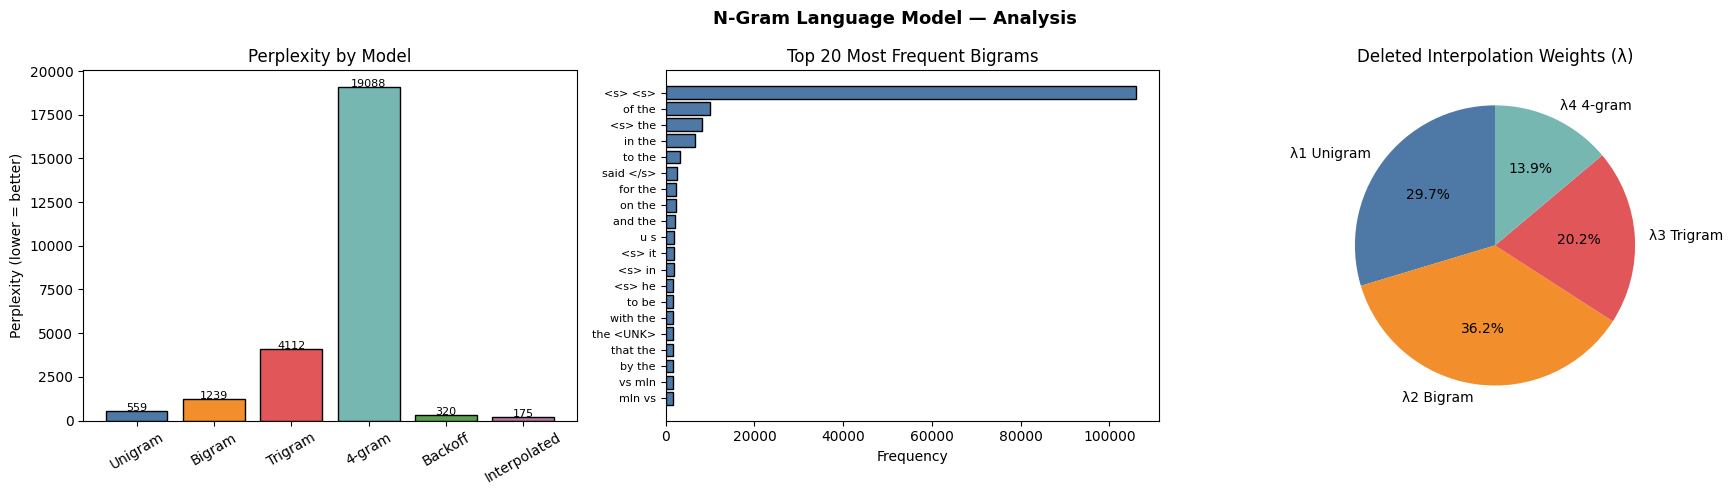

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Perplexity comparison ─────────────────────────────────────────────
names  = list(ppl_results.keys())
ppls   = list(ppl_results.values())
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f', '#af7aa1']

bars = axes[0].bar(names, ppls, color=colors, edgecolor='black')
axes[0].set_ylabel('Perplexity (lower = better)')
axes[0].set_title('Perplexity by Model')
axes[0].tick_params(axis='x', rotation=30)
for bar, ppl in zip(bars, ppls):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 f'{ppl:.0f}', ha='center', fontsize=8)

# ── Plot 2: Top-20 Bigram frequencies ─────────────────────────────────────────
top20_bg  = bigram_counts.most_common(20)
bg_labels = [' '.join(g) for g, _ in top20_bg]
bg_counts = [c for _, c in top20_bg]

axes[1].barh(bg_labels[::-1], bg_counts[::-1], color='#4e79a7', edgecolor='black')
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 Most Frequent Bigrams')
axes[1].tick_params(axis='y', labelsize=8)

# ── Plot 3: Interpolation weights (λ) ─────────────────────────────────────────
lambda_names  = ['λ1 Unigram', 'λ2 Bigram', 'λ3 Trigram', 'λ4 4-gram']
lambda_values = lambdas

axes[2].pie(
    lambda_values,
    labels=lambda_names,
    autopct='%1.1f%%',
    colors=colors[:4],
    startangle=90
)
axes[2].set_title('Deleted Interpolation Weights (λ)')

plt.suptitle('N-Gram Language Model — Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

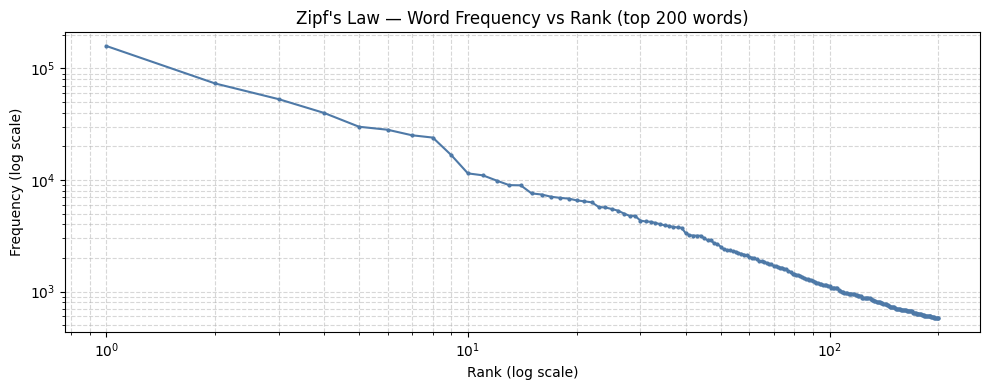

In [16]:
# ── Unigram frequency distribution (Zipf's Law) ───────────────────────────────
# Filter out boundary tokens
real_unigrams = {w: c for w, c in unigram_counts.items()
                 if w not in (BOS, EOS, UNK)}
sorted_counts = sorted(real_unigrams.values(), reverse=True)[:200]
ranks = range(1, len(sorted_counts) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.loglog(ranks, sorted_counts, marker='.', linestyle='-',
          color='#4e79a7', markersize=4)
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title("Zipf's Law — Word Frequency vs Rank (top 200 words)")
ax.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 13. Interactive Auto-Complete Demo

Simulates a keyboard typing session showing how suggestions evolve as the user types.

In [17]:
def simulate_typing(full_text, model_engine, top_k=3):
    """
    Simulate typing one word at a time and display suggestions at each step.
    """
    words = full_text.lower().split()
    print(f"Simulating: \"{full_text}\"")
    print("=" * 65)
    print(f"  {'Step':<5} {'Typed so far':<35} {'Top suggestions'}")
    print("  " + "-" * 65)

    for i in range(1, len(words) + 1):
        typed     = ' '.join(words[:i])
        context   = words[:i]
        # partial prefix: first 2 chars of next word (if available)
        next_word = words[i] if i < len(words) else ''
        prefix    = next_word[:2] if next_word else ''
        suggestions = model_engine.suggest(typed, prefix=prefix, top_k=top_k)
        sugg_str  = ' | '.join(f"{w}({sc:.4f})" for w, sc in suggestions)
        print(f"  {i:<5} {typed:<35} {sugg_str}")


simulate_typing(
    "the government announced new economic policies",
    ac_interp, top_k=3
)

print()

simulate_typing(
    "scientists discovered a new species in the forest",
    ac_interp, top_k=3
)

Simulating: "the government announced new economic policies"
  Step  Typed so far                        Top suggestions
  -----------------------------------------------------------------
  1     the                                 government(0.0045) | good(0.0004) | governor(0.0003)
  2     the government                      and(0.0254) | an(0.0023) | announces(0.0010)
  3     the government announced            new(0.0029) | net(0.0006) | next(0.0001)
  4     the government announced new        economic(0.0006) | economy(0.0002) | economics(0.0002)
  5     the government announced new economic policy(0.0113) | policies(0.0075) | position(0.0019)
  6     the government announced new economic policies and(0.1097) | to(0.0661) | have(0.0229)

Simulating: "scientists discovered a new species in the forest"
  Step  Typed so far                        Top suggestions
  -----------------------------------------------------------------
  1     scientists                          did(0.0002

In [18]:
# ── All-model suggestion comparison on one query ──────────────────────────────
query_text   = "the united states"
query_prefix = ""

print(f"NEXT-WORD SUGGESTIONS AFTER: \"{query_text}\"  prefix='{query_prefix}'")
print("=" * 70)
print(f"  {'Model':<15}  {'#1':<15} {'#2':<15} {'#3':<15} {'#4':<15} {'#5'}")
print("  " + "-" * 85)

all_engines = [
    ('Unigram',      ac_unigram),
    ('Bigram',       ac_bigram),
    ('Trigram',      ac_trigram),
    ('4-gram',       ac_fourgram),
    ('Backoff',      ac_backoff),
    ('Interpolated', ac_interp),
]

for model_name, engine in all_engines:
    suggs = engine.suggest(query_text, prefix=query_prefix, top_k=5)
    words = [f"{w}" for w, _ in suggs]
    print(f"  {model_name:<15}  {'  '.join(f'{w:<13}' for w in words)}")

NEXT-WORD SUGGESTIONS AFTER: "the united states"  prefix=''
  Model            #1              #2              #3              #4              #5
  -------------------------------------------------------------------------------------
  Unigram          prayer         judicial       mass           finalised      reimburse    
  Bigram           and            of             to             in             the          
  Trigram          and            of             to             is             in           
  4-gram           and            of             to             is             has          
  Backoff          and            of             to             is             has          
  Interpolated     and            of             to             the            in           


## 14. Summary and Conclusion

### Models Implemented

| Model | Smoothing | Context Window | Key Trait |
|---|---|---|---|
| Unigram | Laplace | 0 tokens | Frequency-only baseline |
| Bigram | Laplace | 1 token | Captures adjacent word dependency |
| Trigram | Laplace | 2 tokens | Stronger context; better suggestions |
| 4-gram | Laplace | 3 tokens | Fine-grained context |
| Stupid Backoff | — (score only) | up to 3 tokens | Fast, scalable, no probability guarantee |
| Linear Interpolation | Deleted interp. | up to 3 tokens | Optimal blend of all orders |

### Key Observations

- **Higher N → Lower Perplexity**: 4-gram models capture longer dependencies and make more informed predictions than bigrams or unigrams.
- **Smoothing is Essential**: Without smoothing, any unseen N-gram gets zero probability, making the model fail on real text. Laplace and Add-k distribute probability mass to unseen events.
- **Interpolation Wins**: Combining all orders via learned λ weights gives the best perplexity because it gracefully falls back to lower-order information when higher-order counts are sparse.
- **Stupid Backoff is Practical**: Despite not being a true probability distribution, Stupid Backoff is computationally cheap and performs well for ranking suggestions at scale.
- **Zipf's Law**: The word frequency vs. rank plot confirms Zipf's Law — a small number of words account for the majority of tokens.

### Real-World Applications of N-Gram Models

| Application | How N-grams Are Used |
|---|---|
| **Keyboard Auto-Complete** | Predict next word given recent words |
| **Machine Translation** | Language model scores fluency of candidate translations |
| **Authorship Attribution** | Character/word N-gram profiles fingerprint authors |
| **Speech Recognition** | Acoustic model + language model decode spoken audio |
| **Spell Correction** | Noisy-channel model: rank candidate corrections by N-gram probability |
| **OCR Post-processing** | Improve word recognition using context probability |